# Models pipe

The project's models and their referee, in five steps. Every `predict_*` takes a StudyInstanceUID; every comparison is judged on the 58 human-labelled gold studies.

In [1]:
import sys; sys.path.insert(0, '..')   # repo root, so `functions` and `models` import

**How every model in this notebook is trained** — the shared discipline, stated once:

All five share one discipline: **train on the ~4,349 LLM-derived soft labels (gold excluded), validate on the 58 human-labelled gold studies, monitor `val_auc`** with EarlyStopping (patience 15) + best-only checkpointing + ReduceLROnPlateau. Two choices repeat everywhere, so once for all:

- **12 × sigmoid outputs + binary cross-entropy** — never softmax/categorical: a knee can have an ACL tear *and* an effusion *and* OA at once (multi-label), so each finding gets an independent probability. Binary cross-entropy also accepts our **soft targets** (0.08, 0.94…) unchanged — the LLM's confidence is signal, not noise to round away.
- **Custom `SoftAUC` / `SoftBinaryAccuracy` metrics** — stock Keras metrics assume `y_true ∈ {0,1}` and fail *silently* on soft labels (AUC pins to 0.000, precision to a fake-perfect 1.000). Ours binarize `y_true` at 0.5 inside the metric only; the loss keeps the soft values where the gradient lives.

## 1 — David's model: images → labels

In [2]:
# from functions.predict import predict_study

# predict_study("1.2.826.0.1.3680043.8.498.10004873229099053869093324292195817260")

#### Model card — `image_model`: sagittal 3D CNN (gold 0.754)

| | |
|---|---|
| input | `(K=24, 224, 224, 1)` — 24 slices sampled evenly across the series, one channel (MRI is monochrome; 3 copies would just cost 3× memory) |
| stack | 3 × [`Conv3D(3³)` → `MaxPool3D`], filters 32→64→64, then `GlobalAveragePooling3D` → `Dense(20)` → `Dense(20)` → `Dense(12, sigmoid)` |
| the pooling detail | first pool is `(1,2,2)` — it shrinks the image axes but **keeps all 24 slices**: depth is the scarcest axis (24 vs 224) so it is spent last |
| training | **augmented**: pad-reflect + random-crop (translation), per-volume intensity jitter, light noise. Deliberately **no flips / no slice reversal** — both mirror medial↔lateral anatomy and would silently swap the Medial/Lateral labels. ~117 epochs total (100 + a measured continuation), batch 8 |

**Why 3D convolution**: the kernel moves *through* the slice axis, so a filter sees the same spot on neighbouring slices — a tear that spans slices is a 3D pattern. **Why this card matters historically**: un-augmented, this exact architecture ceiled at gold 0.683; augmentation alone bought **+0.071** — the single largest measured gain of the project.

In [3]:
import keras
_m = keras.saving.load_model("../models/knee_findings.keras", compile=False)
print(f"image_model (sagittal) -- {_m.count_params():,} parameters")
_m.summary(line_length=100)

image_model (sagittal) -- 168,884 parameters


Model: "functional_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)                               ┃ Output Shape                    ┃           Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ input_layer (InputLayer)                   │ (None, 24, 224, 224, 1)         │                 0 │
├────────────────────────────────────────────┼─────────────────────────────────┼───────────────────┤
│ conv3d (Conv3D)                            │ (None, 24, 224, 224, 32)        │               896 │
├────────────────────────────────────────────┼─────────────────────────────────┼───────────────────┤
│ max_pooling3d (MaxPooling3D)               │ (None, 24, 112, 112, 32)        │                 0 │
├────────────────────────────────────────────┼─────────────────────────────────┼───────────────────┤
│ conv3d_1 (Conv3D)                          │ (None, 24, 112, 112, 64)        │            55,360 │
├────────────────────────────────────────────┼─────────────────────────────────┼───────────────────┤
│ max_pooling3d_1 (MaxPooling3D)             │ (None, 12, 56, 56, 64)          │                 0 │
├────────────────────────────────────────────┼─────────────────────────────────┼───────────────────┤
│ conv3d_2 (Conv3D)                          │ (None, 12, 56, 56, 64)          │           110,656 │
├────────────────────────────────────────────┼─────────────────────────────────┼───────────────────┤
│ max_pooling3d_2 (MaxPooling3D)             │ (None, 6, 28, 28, 64)           │                 0 │
├────────────────────────────────────────────┼─────────────────────────────────┼───────────────────┤
│ global_average_pooling3d                   │ (None, 64)                      │                 0 │
│ (GlobalAveragePooling3D)                   │                                 │                   │
├────────────────────────────────────────────┼─────────────────────────────────┼───────────────────┤
│ dense (Dense)                              │ (None, 20)                      │             1,300 │
├────────────────────────────────────────────┼─────────────────────────────────┼───────────────────┤
│ dense_1 (Dense)                            │ (None, 20)                      │               420 │
├────────────────────────────────────────────┼─────────────────────────────────┼───────────────────┤
│ dense_2 (Dense)                            │ (None, 12)                      │               252 │
└────────────────────────────────────────────┴─────────────────────────────────┴───────────────────┘

 Total params: 168,884 (659.70 KB)

 Trainable params: 168,884 (659.70 KB)

 Non-trainable params: 0 (0.00 B)

#### Model card — `image_multiplane`: 3-plane CNN, 3-seed ensemble (gold 0.775)

| | |
|---|---|
| inputs | **three** `(24, 224, 224, 1)` volumes — sagittal + coronal + axial of the *same knee* (verified: 4,407/4,407 studies have all three planes) |
| stack | one **unshared** Conv3D encoder per plane (same 3-block design as 6.1 — sagittal and axial anatomy do not look alike, so no weight sharing) → concat 3×64 = 192 features → shared Dense head → 12 sigmoids. 505k params |
| ensemble | **3 seeds averaged** (0.768 / 0.745 / 0.767 → **0.775**) — the "seeding and folding first" directive, paying +0.007 |

**Why multi-plane**: radiologists read menisci on coronal and effusion on axial — and the per-finding table agrees (Medial Meniscus jumped 0.707→0.827 when coronal arrived). This is the MRNet idea (Stanford's knee-MRI reference work) trained jointly instead of vote-combined.

In [4]:
import keras
_m = keras.saving.load_model("../models/knee_multiplane.keras", compile=False)
print(f"image_multiplane (seed 0 of 3; seeds 1-2 identical in shape) -- {_m.count_params():,} parameters")
_m.summary(line_length=100)

image_multiplane (seed 0 of 3; seeds 1-2 identical in shape) -- 505,268 parameters


Model: "functional_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)                ┃ Output Shape            ┃        Param # ┃ Connected to            ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━┩
│ plane_sagittal (InputLayer) │ (None, 24, 224, 224, 1) │              0 │ -                       │
├─────────────────────────────┼─────────────────────────┼────────────────┼─────────────────────────┤
│ plane_coronal (InputLayer)  │ (None, 24, 224, 224, 1) │              0 │ -                       │
├─────────────────────────────┼─────────────────────────┼────────────────┼─────────────────────────┤
│ plane_axial (InputLayer)    │ (None, 24, 224, 224, 1) │              0 │ -                       │
├─────────────────────────────┼─────────────────────────┼────────────────┼─────────────────────────┤
│ conv3d (Conv3D)             │ (None, 24, 224, 224,    │            896 │ plane_sagittal[0][0]    │
│                             │ 32)                     │                │                         │
├─────────────────────────────┼─────────────────────────┼────────────────┼─────────────────────────┤
│ conv3d_3 (Conv3D)           │ (None, 24, 224, 224,    │            896 │ plane_coronal[0][0]     │
│                             │ 32)                     │                │                         │
├─────────────────────────────┼─────────────────────────┼────────────────┼─────────────────────────┤
│ conv3d_6 (Conv3D)           │ (None, 24, 224, 224,    │            896 │ plane_axial[0][0]       │
│                             │ 32)                     │                │                         │
├─────────────────────────────┼─────────────────────────┼────────────────┼─────────────────────────┤
│ max_pooling3d               │ (None, 24, 112, 112,    │              0 │ conv3d[0][0]            │
│ (MaxPooling3D)              │ 32)                     │                │                         │
├─────────────────────────────┼─────────────────────────┼────────────────┼─────────────────────────┤
│ max_pooling3d_3             │ (None, 24, 112, 112,    │              0 │ conv3d_3[0][0]          │
│ (MaxPooling3D)              │ 32)                     │                │                         │
├─────────────────────────────┼─────────────────────────┼────────────────┼─────────────────────────┤
│ max_pooling3d_6             │ (None, 24, 112, 112,    │              0 │ conv3d_6[0][0]          │
│ (MaxPooling3D)              │ 32)                     │                │                         │
├─────────────────────────────┼─────────────────────────┼────────────────┼─────────────────────────┤
│ conv3d_1 (Conv3D)           │ (None, 24, 112, 112,    │         55,360 │ max_pooling3d[0][0]     │
│                             │ 64)                     │                │                         │
├─────────────────────────────┼─────────────────────────┼────────────────┼─────────────────────────┤
│ conv3d_4 (Conv3D)           │ (None, 24, 112, 112,    │         55,360 │ max_pooling3d_3[0][0]   │
│                             │ 64)                     │                │                         │
├─────────────────────────────┼─────────────────────────┼────────────────┼─────────────────────────┤
│ conv3d_7 (Conv3D)           │ (None, 24, 112, 112,    │         55,360 │ max_pooling3d_6[0][0]   │
│                             │ 64)                     │                │                         │
├─────────────────────────────┼─────────────────────────┼────────────────┼─────────────────────────┤
│ max_pooling3d_1             │ (None, 12, 56, 56, 64)  │              0 │ conv3d_1[0][0]          │
│ (MaxPooling3D)              │                         │                │                         │
├─────────────────────────────┼─────────────────────────┼────────────────┼─────────────────────────┤
│ max_pooling3d_4             │ (None, 12, 56, 56, 64)  │    

 Total params: 505,268 (1.93 MB)

 Trainable params: 505,268 (1.93 MB)

 Non-trainable params: 0 (0.00 B)

## 2 — David vs LLM
The image model against every LLM report reader. Prints a notice until the image checkpoint is trained.

In [5]:
from models.evaluate_labels import image_model_vs_llm, styled

t = image_model_vs_llm()
styled(t) if t is not None else t

,positives,llm_v4_blend,llm_full,llm_v2,pilkwang_v2,image_model
label,,,,,,
ACL,24.000,0.987,0.993,0.993,0.997,0.784
MCL,9.000,0.968,0.964,0.964,0.976,0.621
Medial Meniscus,26.000,0.948,0.954,0.954,0.943,0.709
Lateral Meniscus,23.000,0.879,0.862,0.862,0.841,0.804
Medial OA,15.000,0.932,0.931,0.931,0.908,0.901
Lateral OA,11.000,0.833,0.830,0.830,0.789,0.723
PF OA,21.000,0.902,0.901,0.901,0.891,0.773
Effusion,35.000,0.877,0.853,0.853,0.830,0.925
Synovitis,27.000,0.790,0.678,0.790,0.694,0.736


## 3 — Kevin's model: report → labels

In [6]:
# from models.report_model import predict_report

# predict_report("1.2.826.0.1.3680043.8.498.10004873229099053869093324292195817260")

#### Model card — `report_model`: TF-IDF + dense head (gold 0.855)

| | |
|---|---|
| input | TF-IDF vector, **10,000 features, 1–3-grams**, sublinear tf, min_df 3 — vocabulary *learned from the corpus*, zero hand-written terms. Fitted on training reports only (letting gold shape the idf weights would leak the referee into the features) |
| text source | all 4,407 reports machine-translated to English once, cached (`reports_en.csv`) — 8 source languages |
| stack | `Dense(512, relu)` → `Dropout(0.3)` → `Dense(128, relu)` → `Dropout(0.15)` → `Dense(12, sigmoid)` |
| tuning | winner of a **108-configuration sweep** (features × n-grams × width × dropout × seeds) |

**Why TF-IDF and not embeddings**: measured, not assumed — universal-sentence-encoder embeddings scored 0.817 vs TF-IDF's 0.855. Findings live in exact terms ("effusion", "ACL rupture"); sparse n-grams preserve them, a 512-dim "gist" vector blurs them. **Why trigrams**: the sweep chose *fewer* features but richer phrases — "anterior cruciate ligament" is one signal, not three.

In [7]:
import keras
_m = keras.saving.load_model("../models/report_model.keras", compile=False)
print(f"report_model -- {_m.count_params():,} parameters")
_m.summary(line_length=100)

report_model -- 5,187,724 parameters


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)                               ┃ Output Shape                    ┃           Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ dense (Dense)                              │ (None, 512)                     │         5,120,512 │
├────────────────────────────────────────────┼─────────────────────────────────┼───────────────────┤
│ dropout (Dropout)                          │ (None, 512)                     │                 0 │
├────────────────────────────────────────────┼─────────────────────────────────┼───────────────────┤
│ dense_1 (Dense)                            │ (None, 128)                     │            65,664 │
├────────────────────────────────────────────┼─────────────────────────────────┼───────────────────┤
│ dropout_1 (Dropout)                        │ (None, 128)                     │                 0 │
├────────────────────────────────────────────┼─────────────────────────────────┼───────────────────┤
│ findings (Dense)                           │ (None, 12)                      │             1,548 │
└────────────────────────────────────────────┴─────────────────────────────────┴───────────────────┘

 Total params: 5,187,724 (19.79 MB)

 Trainable params: 5,187,724 (19.79 MB)

 Non-trainable params: 0 (0.00 B)

#### Model card — `report_bagged`: TF-IDF + medical terms, 10-model bag (gold 0.858)

| | |
|---|---|
| input | the 6.3 features **plus 267 medical-term count features** (log1p of per-term regex counts) — Kevin's hand-built dictionary, demoted from *rules that decide* to *features the model weighs*. The term list is a data file (`medical_terms.txt`), not code |
| ensemble | **5 folds × 2 seeds = 10 models**, each trained on 4/5 of the data, gold predictions averaged. No single artifact — the ensemble *is* the model |

**Why the terms only appear here**: measured twice — they *hurt* a single model (0.845 vs 0.855) but *help* the bag (0.854→0.858). They add variance that averaging exploits and a lone model pays for. **The historical footnote worth telling**: these same terms scored 0.690 as a rule engine — as learned features they are worth +0.075 more. Vocabulary was never the problem; hardcoded *decisions* were.

## 4 — Kevin vs LLM

In [8]:
from models.evaluate_labels import report_model_vs_llm, styled

t = report_model_vs_llm()
styled(t) if t is not None else t

,positives,llm_v4_blend,llm_full,llm_v2,pilkwang_v2,report_model
label,,,,,,
ACL,24.000,0.987,0.993,0.993,0.997,0.913
MCL,9.000,0.968,0.964,0.964,0.976,0.909
Medial Meniscus,26.000,0.948,0.954,0.954,0.943,0.923
Lateral Meniscus,23.000,0.879,0.862,0.862,0.841,0.809
Medial OA,15.000,0.932,0.931,0.931,0.908,0.932
Lateral OA,11.000,0.833,0.830,0.830,0.789,0.830
PF OA,21.000,0.902,0.901,0.901,0.891,0.857
Effusion,35.000,0.877,0.853,0.853,0.830,0.652
Synovitis,27.000,0.790,0.678,0.790,0.694,0.779


## 5 — DAVID vs the best report reader
Images against whichever report-side reader (Kevin's model or an LLM table) scores best. `images_win` marks the findings where the pixels beat the report pipeline — the doctor-missed-it signal.

In [9]:
from models.evaluate_labels import david_vs_best_reader, styled

t = david_vs_best_reader()
styled(t) if t is not None else t

best report-side reader: llm_v4_blend


,positives,image_model,llm_v4_blend,images_win
label,,,,
ACL,24.000,0.784,0.987,False
MCL,9.000,0.621,0.968,False
Medial Meniscus,26.000,0.709,0.948,False
Lateral Meniscus,23.000,0.804,0.879,False
Medial OA,15.000,0.901,0.932,False
Lateral OA,11.000,0.723,0.833,False
PF OA,21.000,0.773,0.902,False
Effusion,35.000,0.925,0.877,True
Synovitis,27.000,0.736,0.790,False


## 6 — The fusion model

#### Model card — `fusion_model`: images + report, jointly trained, v2 ×2 seeds (gold 0.879)

| | |
|---|---|
| inputs | **four**: the three plane volumes of 6.2 **+** the report's 10k TF-IDF vector (reusing 6.3's fitted vectorizer — identical text features, no second fit) |
| stack | 3 unshared Conv3D encoders (**warm-started**: all 9 conv layers transplanted from the trained multi-plane checkpoint) + text branch `Dense(256)`→`Dropout`→`Dense(64)` → concat 256 features → shared head → 12 sigmoids. 3.08M params |
| training | augmentation on images only + **mixup** (per-batch Beta(0.2) blending of volumes, text vectors *and* soft labels — soft targets make mixup natural) · 2 seeds averaged |

**Why fusion at all**: the modalities are measurably complementary — images own Effusion (0.93), text owns ACL (0.92); even a plain 50/50 average of the finished models scored 0.877. Joint training lets the head learn *per-finding* trust instead of one fixed vote. **Why warm-start**: fusion v1, trained from scratch, blended to mediocrity (0.855, losing Effusion); transplanting the trained image encoders let the head start from working features — v2 single-seed hit **0.873**, the best single model in the project. The ensemble's 0.879 sits 0.014 from the LLM teacher — a ceiling that only better teachers or more human labels move, since these models never saw a human label in training.

In [10]:
import keras
_m = keras.saving.load_model("../models/knee_fusion.keras", compile=False)
print(f"fusion_model (v2 seed 0 of 2) -- {_m.count_params():,} parameters")
_m.summary(line_length=100)

fusion_model (v2 seed 0 of 2) -- 3,083,252 parameters


Model: "functional_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)                ┃ Output Shape            ┃        Param # ┃ Connected to            ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━┩
│ plane_sagittal (InputLayer) │ (None, 24, 224, 224, 1) │              0 │ -                       │
├─────────────────────────────┼─────────────────────────┼────────────────┼─────────────────────────┤
│ plane_coronal (InputLayer)  │ (None, 24, 224, 224, 1) │              0 │ -                       │
├─────────────────────────────┼─────────────────────────┼────────────────┼─────────────────────────┤
│ plane_axial (InputLayer)    │ (None, 24, 224, 224, 1) │              0 │ -                       │
├─────────────────────────────┼─────────────────────────┼────────────────┼─────────────────────────┤
│ conv3d (Conv3D)             │ (None, 24, 224, 224,    │            896 │ plane_sagittal[0][0]    │
│                             │ 32)                     │                │                         │
├─────────────────────────────┼─────────────────────────┼────────────────┼─────────────────────────┤
│ conv3d_3 (Conv3D)           │ (None, 24, 224, 224,    │            896 │ plane_coronal[0][0]     │
│                             │ 32)                     │                │                         │
├─────────────────────────────┼─────────────────────────┼────────────────┼─────────────────────────┤
│ conv3d_6 (Conv3D)           │ (None, 24, 224, 224,    │            896 │ plane_axial[0][0]       │
│                             │ 32)                     │                │                         │
├─────────────────────────────┼─────────────────────────┼────────────────┼─────────────────────────┤
│ max_pooling3d               │ (None, 24, 112, 112,    │              0 │ conv3d[0][0]            │
│ (MaxPooling3D)              │ 32)                     │                │                         │
├─────────────────────────────┼─────────────────────────┼────────────────┼─────────────────────────┤
│ max_pooling3d_3             │ (None, 24, 112, 112,    │              0 │ conv3d_3[0][0]          │
│ (MaxPooling3D)              │ 32)                     │                │                         │
├─────────────────────────────┼─────────────────────────┼────────────────┼─────────────────────────┤
│ max_pooling3d_6             │ (None, 24, 112, 112,    │              0 │ conv3d_6[0][0]          │
│ (MaxPooling3D)              │ 32)                     │                │                         │
├─────────────────────────────┼─────────────────────────┼────────────────┼─────────────────────────┤
│ conv3d_1 (Conv3D)           │ (None, 24, 112, 112,    │         55,360 │ max_pooling3d[0][0]     │
│                             │ 64)                     │                │                         │
├─────────────────────────────┼─────────────────────────┼────────────────┼─────────────────────────┤
│ conv3d_4 (Conv3D)           │ (None, 24, 112, 112,    │         55,360 │ max_pooling3d_3[0][0]   │
│                             │ 64)                     │                │                         │
├─────────────────────────────┼─────────────────────────┼────────────────┼─────────────────────────┤
│ conv3d_7 (Conv3D)           │ (None, 24, 112, 112,    │         55,360 │ max_pooling3d_6[0][0]   │
│                             │ 64)                     │                │                         │
├─────────────────────────────┼─────────────────────────┼────────────────┼─────────────────────────┤
│ max_pooling3d_1             │ (None, 12, 56, 56, 64)  │              0 │ conv3d_1[0][0]          │
│ (MaxPooling3D)              │                         │                │                         │
├─────────────────────────────┼─────────────────────────┼────────────────┼─────────────────────────┤
│ max_pooling3d_4             │ (None, 12, 56, 56, 64)  │    

 Total params: 3,083,252 (11.76 MB)

 Trainable params: 3,083,252 (11.76 MB)

 Non-trainable params: 0 (0.00 B)

## 7 — The full report
Every reader on one sheet: LLM readers, both image models (sagittal serving + multi-plane), Kevin's model, and the **fusion model** (images + report, jointly trained — its column appears once `train_fusion` has run). Blue = beats every LLM reader on that finding.

In [11]:
from models.evaluate_labels import final_table, styled

styled(final_table())

,positives,llm_v4_blend,llm_full,llm_v2,pilkwang_v2,image_model,image_multiplane,report_model,report_bagged,fusion_model
label,,,,,,,,,,
ACL,24.000,0.987,0.993,0.993,0.997,0.784,0.800,0.913,0.925,0.911
MCL,9.000,0.968,0.964,0.964,0.976,0.621,0.583,0.909,0.925,0.902
Medial Meniscus,26.000,0.948,0.954,0.954,0.943,0.709,0.840,0.923,0.931,0.939
Lateral Meniscus,23.000,0.879,0.862,0.862,0.841,0.804,0.734,0.809,0.800,0.835
Medial OA,15.000,0.932,0.931,0.931,0.908,0.901,0.899,0.932,0.933,0.936
Lateral OA,11.000,0.833,0.830,0.830,0.789,0.723,0.754,0.830,0.812,0.847
PF OA,21.000,0.902,0.901,0.901,0.891,0.773,0.786,0.857,0.874,0.871
Effusion,35.000,0.877,0.853,0.853,0.830,0.925,0.930,0.652,0.677,0.851
Synovitis,27.000,0.790,0.678,0.790,0.694,0.736,0.743,0.779,0.774,0.789


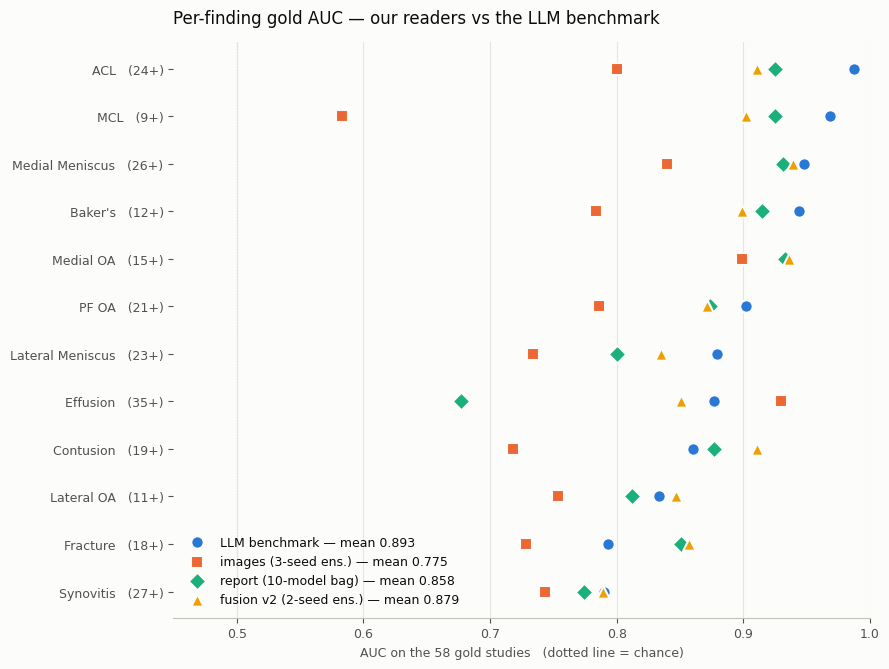

In [12]:
from models.evaluate_labels import plot_readers

_ = plot_readers()

## 8 — Which reports missed something?
Worst reports first: per study, **what the report claimed** vs **what the images think it should be** (both at gold-calibrated balanced cuts), and `missed?` = only the validated flags (image accusation types that earned ≥50% precision on the 58 gold studies). Full corpus table: `data/meta/report_quality.csv`.

In [13]:
from models.report_quality import run, verdict_sheet

_ = run(top=0)             # calibrate + validate + score the corpus (prints the certificates)
verdict_sheet(20)          # the sheet: what the report said vs what the images think

flag validation on the 58 gold studies (precision = when images accused the report, gold sided with the images):
                  gold_flags  flag_precision
label                                       
ACL                        2           0.000
MCL                        1           0.000
Medial Meniscus            5           0.400
Lateral Meniscus           2           0.500
Medial OA                  2           0.000
Lateral OA                 0             NaN
PF OA                      1           0.000
Effusion                   0             NaN
Synovitis                  3           0.333
Baker's                    4           0.250
Contusion                  2           0.500
Fracture                   4           0.500 

corpus scored: 4406 reports | flagging enabled for: ['Lateral Meniscus', 'Contusion', 'Fracture']
reports with >=1 validated flag: 469 (10.6%) | >=2: 115

the 0 most suspicious reports:
Empty DataFrame
Columns: [StudyInstanceUID, n_flags, flagged_findings

,StudyInstanceUID,report_says,images_say,missed?,quality_score
0,1.2.826.0.1.3680043.8.498.11468812519969607938...,"ACL, Effusion, Baker's","ACL, MCL, Medial Meniscus, Lateral Meniscus, E...","Lateral Meniscus, Contusion, Fracture",0.500
1,1.2.826.0.1.3680043.8.498.30978547345367837000...,"ACL, MCL, Medial OA, PF OA, Effusion, Synovitis","ACL, Medial Meniscus, Lateral Meniscus, Medial...","Lateral Meniscus, Contusion, Fracture",0.500
2,1.2.826.0.1.3680043.8.498.69411539430142524612...,"ACL, MCL, Medial Meniscus, Medial OA, Lateral ...","ACL, Medial Meniscus, Lateral Meniscus, Medial...","Lateral Meniscus, Contusion, Fracture",0.500
3,1.2.826.0.1.3680043.8.498.74095402538454760179...,"ACL, MCL, Medial Meniscus, Medial OA, Effusion...","ACL, MCL, Medial Meniscus, Lateral Meniscus, M...","Lateral Meniscus, Contusion, Fracture",0.500
4,1.2.826.0.1.3680043.8.498.93344237572402384894...,"MCL, Effusion, Synovitis","ACL, MCL, Medial Meniscus, Lateral Meniscus, M...","Lateral Meniscus, Contusion, Fracture",0.500
5,1.2.826.0.1.3680043.8.498.11880385031047315524...,"ACL, MCL, Medial Meniscus, PF OA, Effusion","ACL, MCL, Medial Meniscus, Lateral Meniscus, M...","Lateral Meniscus, Contusion, Fracture",0.500
6,1.2.826.0.1.3680043.8.498.10252121617380434672...,"Effusion, Synovitis","ACL, Effusion, Contusion, Fracture","Contusion, Fracture",0.667
7,1.2.826.0.1.3680043.8.498.11610585947047502123...,"MCL, Lateral Meniscus","ACL, Effusion, Contusion, Fracture","Contusion, Fracture",0.667
8,1.2.826.0.1.3680043.8.498.89045629523485194086...,"MCL, Lateral Meniscus","ACL, Medial Meniscus, Effusion, Contusion, Fra...","Contusion, Fracture",0.667
9,1.2.826.0.1.3680043.8.498.89190511197564127079...,"MCL, Lateral Meniscus","ACL, Medial Meniscus, Effusion, Fracture","Contusion, Fracture",0.667
